In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

In [2]:

model_name = "Qwen/Qwen3-4B"

# load the tokenizer and the model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype="auto",
    # device_map="auto"
    device_map={"": "cuda:0"},
)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [35]:
w = model.model.layers[0].mlp.down_proj.weight.data

NameError: name 'model' is not defined

In [36]:
w = batch

In [37]:
import matplotlib.pyplot as plt

(array([1.19209290e-08, 1.19209290e-08, 1.19209290e-08, 2.38418579e-08,
        4.76837158e-08, 5.96046448e-08, 8.34465027e-08, 1.07288361e-07,
        1.31130219e-07, 2.14576721e-07, 2.62260437e-07, 3.45706940e-07,
        5.60283661e-07, 7.98702240e-07, 1.06096268e-06, 1.69277191e-06,
        2.59876251e-06, 3.92198563e-06, 5.63859940e-06, 7.92741776e-06,
        1.13368034e-05, 1.61647797e-05, 2.24947929e-05, 3.22222710e-05,
        4.57167625e-05, 6.44922256e-05, 9.13143158e-05, 1.29473209e-04,
        1.83808804e-04, 2.56872177e-04, 3.63278389e-04, 5.17153740e-04,
        7.29179382e-04, 1.02775097e-03, 1.44708157e-03, 2.03953981e-03,
        2.88490057e-03, 4.06717062e-03, 5.68848848e-03, 8.04363489e-03,
        1.13266349e-02, 1.58907413e-02, 2.22647429e-02, 3.11844707e-02,
        4.36500072e-02, 6.06093407e-02, 8.35036516e-02, 1.14815402e-01,
        1.56877041e-01, 2.13596058e-01, 2.90329909e-01, 3.92587686e-01,
        5.20112455e-01, 6.71059632e-01, 8.20297694e-01, 9.334065

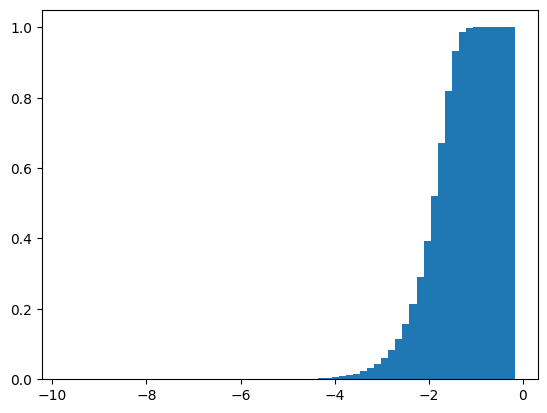

In [38]:
plt.hist(w.abs().float().log10().view(-1).cpu(),bins=64,density=True, cumulative=True)

In [39]:
import pandas as pd

def print_tensor_stats(x: torch.Tensor, name: str = "x", qs=None, precision: int = 6) -> pd.Series:
    """
    Print detailed stats for a (flat or flattenable) torch Tensor using pandas.
    Focuses on q05..q95 plus median, mean, std, min, max, etc.

    Returns the pandas Series of stats (so you can log/save it).
    """
    if qs is None:
        qs = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

    # Flatten, drop non-finite, move to CPU for pandas
    t = x.detach().reshape(-1)
    t = t[torch.isfinite(t)]
    n_total = x.numel()
    n = t.numel()

    if n == 0:
        s = pd.Series(
            {
                "name": name,
                "numel_total": int(n_total),
                "numel_finite": 0,
                "dtype": str(x.dtype),
                "device": str(x.device),
            }
        )
        print(s.to_string())
        return s

    v = t.float().cpu().numpy()
    ser = pd.Series(v, name=name)

    # pandas describe + extra quantiles
    q = ser.quantile(qs)
    q.index = [f"q{int(round(p*100)):02d}" for p in qs]

    out = pd.Series(
        {
            "name": name,
            "dtype": str(x.dtype),
            "device": str(x.device),
            "numel_total": int(n_total),
            "numel_finite": int(n),
            "numel_nonfinite": int(n_total - n),
            "min": float(ser.min()),
            "max": float(ser.max()),
            "mean": float(ser.mean()),
            "std": float(ser.std(ddof=1)),
            "median": float(ser.median()),
            "mad_median": float((ser - ser.median()).abs().median()),
            "zeros": int((ser == 0).sum()),
            "neg": int((ser < 0).sum()),
            "pos": int((ser > 0).sum()),
        }
    )

    stats = pd.concat([out, q])

    # Pretty print
    with pd.option_context("display.precision", precision):
        print(stats.to_string())

    return stats


# Example:
# x = torch.randn(1_000_000, device="cuda")
# print_tensor_stats(x, name="randn")

In [40]:
x = w.abs().float().log10().view(-1).cpu()
print_tensor_stats(x, name="down_proj")

name                   down_proj
dtype              torch.float32
device                       cpu
numel_total             83886080
numel_finite            83886080
numel_nonfinite                0
min                    -9.744534
max                    -0.165202
mean                   -1.945601
std                     0.516972
median                 -1.834209
mad_median              0.285042
zeros                          0
neg                     83886080
pos                            0
q01                    -3.662665
q05                    -2.947248
q10                    -2.626148
q25                    -2.185036
q50                    -1.834209
q75                     -1.58501
q90                     -1.41646
q95                    -1.331327
q99                    -1.190756


name                   down_proj
dtype              torch.float32
device                       cpu
numel_total             83886080
numel_finite            83886080
numel_nonfinite                0
min                    -9.744534
max                    -0.165202
mean                   -1.945601
std                     0.516972
median                 -1.834209
mad_median              0.285042
zeros                          0
neg                     83886080
pos                            0
q01                    -3.662665
q05                    -2.947248
q10                    -2.626148
q25                    -2.185036
q50                    -1.834209
q75                     -1.58501
q90                     -1.41646
q95                    -1.331327
q99                    -1.190756
dtype: object

In [6]:
all_weights = torch.cat([model.model.embed_tokens.weight.data.cpu(),
                         model.lm_head.weight.data.cpu()], dim=0)

In [7]:
for layer in model.model.layers:
    all_weights = torch.cat([all_weights,
                                layer.self_attn.q_proj.weight.data.cpu(),
                                layer.self_attn.k_proj.weight.data.cpu(),
                                layer.self_attn.v_proj.weight.data.cpu(),
                                layer.mlp.gate_proj.weight.data.cpu(),
                                layer.mlp.up_proj.weight.data.cpu()], dim=0)

In [8]:
# torch.save(all_weights, "/tmp/qwen3_8b_input_facing_weights.pt")
# torch.save(all_weights, "/tmp/qwen3_4b_input_facing_weights.pt")

In [2]:
# all_weights = torch.load("/tmp/qwen3_8b_input_facing_weights.pt")
all_weights = torch.load("/tmp/qwen3_4b_input_facing_weights.pt")

In [3]:
all_weights.shape

torch.Size([1225472, 2560])

In [54]:
# batch = embed_tokens[:4096]
batch = all_weights[torch.randperm(all_weights.shape[0])[:4096*2]].to("cuda:1")

In [55]:
batch

tensor([[-1.4801e-03, -2.9907e-03, -4.6692e-03,  ..., -6.9885e-03,
          3.0029e-02, -4.1992e-02],
        [-8.0566e-03, -6.8970e-03, -2.3804e-02,  ...,  1.2131e-03,
         -2.0142e-02, -4.0039e-02],
        [-4.4346e-05, -1.9409e-02,  5.9509e-03,  ..., -9.5825e-03,
         -3.2227e-02, -1.7456e-02],
        ...,
        [ 2.6245e-03,  1.1597e-03,  1.2146e-02,  ..., -5.5237e-03,
          3.3936e-02, -6.1646e-03],
        [ 2.4567e-03,  2.1851e-02,  1.9653e-02,  ..., -9.3994e-03,
          2.8076e-02, -1.4496e-03],
        [ 6.9275e-03, -1.0986e-02,  7.9346e-03,  ..., -1.1475e-02,
         -2.8534e-03, -7.4707e-02]], device='cuda:1', dtype=torch.bfloat16)

In [8]:
import torch

# Define the desired shape (must be 2D, e.g., 5x5 for a square matrix)
rows= cols = batch.shape[1]

# Create an empty tensor
orthogonal_matrix = torch.empty(rows, cols).to(batch).float()

# Fill the tensor with an orthogonal matrix using in-place operation
# torch.nn.init.orthogonal_(orthogonal_matrix)

# Verify orthogonality (M @ M^T should be close to identity)
# identity_check = torch.matmul(orthogonal_matrix, orthogonal_matrix.T)
# print("Orthogonality check (should be close to identity):\n", identity_check)

In [9]:
# orthogonal_matrix.mm(orthogonal_matrix.t())

In [10]:
# batch = batch.float().mm(orthogonal_matrix).half()

In [56]:
batch

tensor([[-1.4801e-03, -2.9907e-03, -4.6692e-03,  ..., -6.9885e-03,
          3.0029e-02, -4.1992e-02],
        [-8.0566e-03, -6.8970e-03, -2.3804e-02,  ...,  1.2131e-03,
         -2.0142e-02, -4.0039e-02],
        [-4.4346e-05, -1.9409e-02,  5.9509e-03,  ..., -9.5825e-03,
         -3.2227e-02, -1.7456e-02],
        ...,
        [ 2.6245e-03,  1.1597e-03,  1.2146e-02,  ..., -5.5237e-03,
          3.3936e-02, -6.1646e-03],
        [ 2.4567e-03,  2.1851e-02,  1.9653e-02,  ..., -9.3994e-03,
          2.8076e-02, -1.4496e-03],
        [ 6.9275e-03, -1.0986e-02,  7.9346e-03,  ..., -1.1475e-02,
         -2.8534e-03, -7.4707e-02]], device='cuda:1', dtype=torch.bfloat16)

In [57]:
block_size = 16
num_blocks = batch.shape[1] // block_size

In [ ]:
# batch.shape = (512, 4096)

block_size = 32
num_blocks = batch.shape[1] // block_size
doubled_mxfp4 = torch.tensor([0, 1, 2, 3, 4, 6, 8, 12, 0, -1, -2, -3, -4, -6, -8, -12]).to(batch)
def quantize_batch(batch, expo_offset=0):
    scale_exponent = batch.view(-1, num_blocks, block_size).abs().amax(dim=-1).log2().add(-2 + 127+expo_offset).floor()
    scale = torch.pow(2, scale_exponent - 128) # 2^(exponent - 127) / 2

    possible_values = (scale.unsqueeze(-1) * doubled_mxfp4.unsqueeze(0).unsqueeze(0)).unsqueeze(-2)

    deltas= batch.view(-1, num_blocks, block_size, 1)- possible_values
    doubled_fp4_quants = doubled_mxfp4[deltas.abs().argmin(dim=-1)]

    dequants = (scale.unsqueeze(-1) * doubled_fp4_quants)

    delta_norm = torch.linalg.norm((batch.view(-1,num_blocks,block_size) - dequants).float(), dim=-1)
    return scale, doubled_fp4_quants, dequants, delta_norm


In [59]:
scale, quants, dequants, delta_norm = quantize_batch(batch)

In [60]:
delta_norm.mean(0).min(), delta_norm.mean(0).max()

(tensor(0.0094, device='cuda:1'), tensor(0.0102, device='cuda:1'))

In [61]:
batch.norm(), delta_norm.pow(2).sum().sqrt()

(tensor(107., device='cuda:1', dtype=torch.bfloat16),
 tensor(11.9361, device='cuda:1'))

In [47]:
scale, quants, dequants, delta_norm = quantize_batch(batch[:,perm])

In [48]:
batch.norm(), delta_norm.pow(2).sum().sqrt()

(tensor(214., device='cuda:1', dtype=torch.bfloat16),
 tensor(23.9166, device='cuda:1'))

In [23]:
dequants[0,0]

tensor([ 0.0000, -0.0039,  0.0156, -0.0078,  0.0039, -0.0117,  0.0156, -0.0234,
        -0.0312, -0.0039,  0.0156, -0.0312, -0.0078,  0.0117, -0.0156,  0.0156],
       device='cuda:1', dtype=torch.bfloat16)

In [24]:
batch[0][:16]

tensor([ 0.0004, -0.0034,  0.0161, -0.0079,  0.0023, -0.0110,  0.0145, -0.0206,
        -0.0347, -0.0044,  0.0145, -0.0278, -0.0073,  0.0132, -0.0150,  0.0178],
       device='cuda:1', dtype=torch.bfloat16)

In [30]:
import torch
import torch.nn.functional as F
import numpy as np
from scipy.optimize import linear_sum_assignment

class BlockPermutationOptimizer:
    def __init__(self, block_size=16, device='cuda'):
        self.block_size = block_size
        self.device = device
        
        # Define the FP4 magnitudes (E2M1 flavor based on provided tensor)
        # doubled_mxfp4: [0, 1, 2, 3, 4, 6, 8, 12, ...]
        # Magnitudes: 0, 1, 2, 3, 4, 6, 8, 12
        magnitudes = torch.tensor([1.0, 2.0, 3.0, 4.0, 6.0, 8.0, 12.0], device=self.device)
        self.log_mags = torch.log2(magnitudes)
        
        # Precompute valid log-space gaps (all pairwise differences)
        # These are the "shifts" allowed between two numbers sharing a scale.
        gaps = self.log_mags.unsqueeze(0) - self.log_mags.unsqueeze(1)
        self.valid_gaps = gaps.view(-1).unique()

    def _compute_gap_affinity(self, weight_matrix, subsample_rows=1024):
        """
        Computes the adjacency matrix based on Scale Invariant Gap-Match error.
        weight_matrix: (M, K)
        """
        M, K = weight_matrix.shape
        
        # 1. Feature Extraction: Log Space
        # Subsample rows for speed if matrix is huge, as column statistics are robust
        if M > subsample_rows:
            indices = torch.randperm(M)[:subsample_rows]
            w_sub = weight_matrix[indices]
        else:
            w_sub = weight_matrix
            
        # Add epsilon and log
        # Shape: (sub_M, K)
        Y = torch.log2(torch.abs(w_sub) + 1e-6)
        
        # 2. Compute Pairwise Distance Matrix
        # We want D[i,j] = mean(min_gap((Y[:,i] - Y[:,j]) - gap)^2)
        # This is memory intensive (K^2), so we batch it.
        
        dist_matrix = torch.zeros((K, K), device=self.device)
        batch_size_k = 64 # Process 64 columns at a time against all K
        
        # Broadcast valid gaps: (1, 1, NumGaps)
        gaps_b = self.valid_gaps.view(1, 1, -1)
        
        for i in range(0, K, batch_size_k):
            end = min(i + batch_size_k, K)
            # Chunk of cols: (M, batch, 1)
            y_chunk = Y[:, i:end].unsqueeze(2) 
            # All cols: (M, 1, K)
            y_all = Y.unsqueeze(1)
            
            # Difference map: (M, batch, K)
            # This is the "Shift" required to align col_i to col_j
            diff = y_chunk - y_all 
            
            # Find distance to nearest valid gap
            # (M, batch, K, 1) - (1, 1, 1, NumGaps)
            # This expands to 4D tensor, can be huge.
            # Optimization: Fold M into batch or iterate M?
            # Let's reduce M first.
            
            # Approximation:
            # Instead of element-wise gap checking which is O(M*K^2),
            # we check gap consistency of the Maxima (which sets the scale)
            # and the Wasserstein-like shape difference.
            
            # Implementation of the user's specific "Gap" request:
            # We calculate error per element.
            # To save memory: (M, batch, K) -> dist to nearest gap
            
            # Compute distance to closest gap for each element difference
            # d_val = min_g |val - g|
            # We can use a fast lookup since gaps are sorted/1D.
            # Here we just broadcast for simplicity (valid_gaps is small, ~30 items)
            
            # (M, batch, K, NumGaps) is too big.
            # Compute (M, batch, K) min directly.
            
            # Only do this if K is small (<1000). For K=4096, this loop is slow.
            # FASTER HEURISTIC:
            # 1. Scale invariant distance: Pearson correlation or Cosine on centered log.
            # 2. Gap penalty: (max_i - max_j) distance to valid gap.
            
            # Let's implement the Max-Gap + Cosine mix.
            # A. Max Gap Error
            max_vals = Y.amax(dim=0) # (K,)
            max_diffs = max_vals[i:end].unsqueeze(1) - max_vals.unsqueeze(0) # (batch, K)
            # Distance of max_diff to nearest valid gap
            gap_dist = (max_diffs.unsqueeze(-1) - self.valid_gaps.view(1,1,-1)).abs().min(dim=-1).values
            
            # B. Shape Similarity (1 - Cosine Sim on centered logs)
            # Center the logs (scale invariance)
            y_chunk_centered = y_chunk - y_chunk.mean(dim=0, keepdim=True)
            y_all_centered = y_all - y_all.mean(dim=0, keepdim=True)
            
            # Normalize
            y_chunk_norm = F.normalize(y_chunk_centered, dim=0) # (M, batch, 1)
            y_all_norm = F.normalize(y_all_centered, dim=0)     # (M, 1, K)
            
            # Cosine similarity -> (batch, K)
            cosine = (y_chunk_norm * y_all_norm).sum(dim=0)
            shape_dist = 1.0 - cosine
            
            # Combined Metric
            # weighted sum
            total_dist = gap_dist + 2.0 * shape_dist
            dist_matrix[i:end, :] = total_dist

        # Symmetrize
        dist_matrix = (dist_matrix + dist_matrix.T) / 2
        
        # Convert to Affinity (Gaussian Kernel)
        # Heuristic sigma: median of distances
        sigma = dist_matrix.median()
        adjacency = torch.exp(- (dist_matrix**2) / (2 * sigma**2 + 1e-8))
        
        # Remove self-loops
        adjacency.fill_diagonal_(0)
        return adjacency

    def find_optimal_permutation(self, weight_matrix):
        """
        Main entry point.
        """
        M, K = weight_matrix.shape
        num_blocks = K // self.block_size
        
        print("1. Computing Gap-Affinity Matrix...")
        adjacency = self._compute_gap_affinity(weight_matrix)
        
        print("2. Spectral Embedding...")
        # Normalized Laplacian: L = I - D^-0.5 A D^-0.5
        d = adjacency.sum(dim=1)
        d_inv_sqrt = torch.pow(d + 1e-6, -0.5)
        d_mat = torch.diag(d_inv_sqrt)
        
        laplacian = torch.eye(K, device=self.device) - d_mat @ adjacency @ d_mat
        
        # Eigen decomposition
        # We need the smallest eigenvectors. 
        # Note: eigh returns eigenvalues in ascending order.
        # The first eigenvector (idx 0) is constant for connected graphs, we skip it?
        # Standard spectral clustering uses bottom k eigenvectors.
        vals, vecs = torch.linalg.eigh(laplacian)
        
        # Use eigenvectors corresponding to smallest eigenvalues
        # We want 'num_blocks' clusters.
        embedding = vecs[:, :num_blocks] 
        
        # Normalize rows to unit sphere
        embedding = F.normalize(embedding, p=2, dim=1)
        
        print("3. Balanced Graph Partitioning (Linear Assignment)...")
        # Initialize centroids (K-Means++)
        # Simplified: Randomly pick indices
        centroids = embedding[torch.randperm(K)[:num_blocks]]
        
        # Iterative Balanced K-Means
        # Since we need strict equality, we solve the Linear Assignment Problem at each step
        # or just once if the initialization is decent. Iterative is better.
        
        embedding_cpu = embedding.cpu().numpy()
        
        # We effectively want to match K points to num_blocks centroids, 
        # where each centroid has capacity 'block_size'.
        # We can simulate this by replicating centroids or tiling the cost matrix.
        
        perm_indices = None
        
        for _ in range(5): # 5 Iterations is usually enough for stability
            # 1. Expand centroids to target size for 1-to-1 matching
            # centroids: (N_blocks, Emb_dim)
            # targets: (K, Emb_dim) -> Each centroid repeated block_size times
            targets = centroids.repeat_interleave(self.block_size, dim=0)
            
            # 2. Compute Cost Matrix (Squared Euclidean)
            # cost[i, j] = ||point_i - target_j||^2
            # Use CPU for Scipy LSA
            centroids_cpu = targets.cpu().numpy()
            
            # Using cdist logic for cost
            # (K, 1, D) - (1, K, D) is huge.
            # But we only really need dist to unique centroids then expand.
            
            # Calculate dist to unique centroids: (K, NumBlocks)
            dists = torch.cdist(embedding, centroids) # (K, NumBlocks)
            dists_sq = dists.pow(2)
            
            # We need to solve assignment for repeated centroids.
            # Cost matrix C is (K, K) where cols are repeated blocks.
            # This is too big for scipy.optimize.linear_sum_assignment if K=4096 (16M entries - feasible).
            
            # Construct full cost matrix for assignment
            # dists_sq: (K, NumBlocks) -> (K, NumBlocks * BlockSize)
            full_cost = dists_sq.repeat_interleave(self.block_size, dim=1).cpu().numpy()
            
            # Solve matching
            row_ind, col_ind = linear_sum_assignment(full_cost)
            
            # col_ind tells us which "slot" each row (atom) went to.
            # The slot index // block_size gives the cluster index.
            cluster_assignments = col_ind // self.block_size
            
            # 3. Update Centroids
            new_centroids = []
            for b in range(num_blocks):
                # indices assigned to block b
                mask = (cluster_assignments == b)
                # Compute mean in embedding space
                # Convert back to torch for mean calc
                cluster_points = embedding[mask]
                if len(cluster_points) > 0:
                    new_centroids.append(cluster_points.mean(dim=0))
                else:
                    new_centroids.append(centroids[b]) # keep old if empty (shouldn't happen)
            
            centroids = torch.stack(new_centroids)
            
            # Save permutation for result
            # We want to arrange W such that columns in cluster 0 come first, then cluster 1...
            # The col_ind gives the target slot 0..K-1.
            # If we sort the original indices by their assigned slot, we get the permutation.
            # col_ind[i] is the slot assigned to original column i.
            # We want an array P such that P[slot] = original_col_index
            # Invert the assignment:
            perm_array = np.zeros(K, dtype=int)
            perm_array[col_ind] = row_ind
            perm_indices = torch.from_numpy(perm_array).to(self.device)

        return perm_indices

# --- Verification & Usage Example ---

# Provided Quantization Function
def quantize_batch_check(batch, block_size, doubled_mxfp4):
    num_blocks = batch.shape[1] // block_size
    
    # Calculate scales (max based)
    # View as (M, N_blocks, B) -> max over B
    scale_exponent = batch.view(-1, num_blocks, block_size).abs().amax(dim=-1).log2().add(-2 + 127).floor()
    scale = torch.pow(2, scale_exponent - 128)
    
    # Reshape for broadcasting
    # scale: (M, N_blocks)
    # vals: (num_vals,)
    # possible: (M, N_blocks, 1, num_vals)
    possible_values = (scale.unsqueeze(-1).unsqueeze(-1) * doubled_mxfp4.view(1, 1, 1, -1))
    
    # batch: (M, N_blocks, B, 1)
    batch_expanded = batch.view(-1, num_blocks, block_size, 1)
    
    # Distance to nearest quant
    deltas = batch_expanded - possible_values
    errors = deltas.abs().min(dim=-1).values
    
    return errors.norm() # Total L2 error


In [43]:
torch.manual_seed(42)
# M, K = 512, 1024
block_size = 16 # Larger block size makes grouping harder/more important
    
    # # Create random weights with structure (some columns large, some small)
    # # Simulating a scenario where shuffling matters
    # W = torch.randn(M, K).cuda()

# W = batch[:4096]
W= batch
M,K = W.shape
    # Artificially scale some columns to create "loud" and "quiet" channels
scales = torch.exp(torch.randn(K).cuda() * 2).to(W)
W = W * scales.view(1, -1)
    
    # Values
doubled_mxfp4 = torch.tensor([0, 1, 2, 3, 4, 6, 8, 12, 0, -1, -2, -3, -4, -6, -8, -12]).float().to(W)
    
    # 1. Baseline Error
err_base = quantize_batch_check(W, block_size, doubled_mxfp4)
print(f"Baseline Quantization Error: {err_base.item():.4f}")
    
# 2. Find Permutation
optimizer = BlockPermutationOptimizer(block_size=block_size, device='cuda:1')
perm = optimizer.find_optimal_permutation(W)
    
# 3. Permuted Error
W_perm = W[:, perm]
err_opt = quantize_batch_check(W_perm, block_size, doubled_mxfp4)
print(f"Optimized Quantization Error: {err_opt.item():.4f}")

print(f"Improvement: {err_base - err_opt:.4f}")

Baseline Quantization Error: 740.0000
1. Computing Gap-Affinity Matrix...
2. Spectral Embedding...
3. Balanced Graph Partitioning (Linear Assignment)...
Optimized Quantization Error: 868.0000
Improvement: -128.0000


In [30]:
scale, quants, dequants_off, delta_norm_off = quantize_batch(batch, expo_offset=-1)
delta_norm_off.mean(0).min(), delta_norm_off.mean(0).max()

(tensor(0.0208, device='cuda:1'), tensor(0.0227, device='cuda:1'))

In [32]:
torch.minimum(delta_norm, delta_norm_off).pow(2).sum().sqrt()

tensor(23.5858, device='cuda:1')

In [37]:
batch.norm(), delta_norm.pow(2).sum().sqrt()

(tensor(214., device='cuda:1', dtype=torch.bfloat16),
 tensor(24.5502, device='cuda:1'))

In [14]:
def quantize_sample(sample, j):
    scale = torch.pow(2,sample.abs().max().log2().add(-2+j + 127).floor()-128)
    sample_fp4 = doubled_mxfp4[(sample[:,None] - doubled_mxfp4[None,:] * scale).abs().argmin(dim=-1)]
    errors = sample-sample_fp4 * scale
    return errors

In [22]:
from tqdm import tqdm
all_best_j = set()
for i in tqdm(range(batch.shape[0])):
    for k in range(batch.shape[1] // block_size):
        sample = batch[i].view(num_blocks,block_size)[k]
        # print(f"Sample {i}")
        ref_errors = quantize_sample(sample, 0).norm()
        best = ref_errors
        best_idx = 0
        for j in range(-4,0):
            errors = quantize_sample(sample, j)
            error_norm = errors.norm()
            # print(f"  j={j}, error norm={error_norm.item()}")
            if error_norm < best:
                best = error_norm
                best_idx = j
        all_best_j.add(best_idx)
    # print(f"  Best error norm: {best}, rel improve: {((best-ref_errors)/ref_errors).item()}, best_j: {best_idx}")
    # print(f" Quant errors: {ref_errors/sample.norm()}, best errors: {best/sample.norm()}")


  5%|▍         | 1541/32768 [02:31<51:13, 10.16it/s]


KeyboardInterrupt: 

In [23]:
all_best_j

{-1, 0}

In [49]:
import torch

# ----------------------------
# 0) FP4 + UE8M0 quant/dequant (matches your reference)
# ----------------------------

def mxfp4_quant_dequant(batch: torch.Tensor):
    """
    batch: (R, K) float tensor
    returns dequants: (R, K), and per-(R,B) L2 block error like your delta_norm
    """
    assert batch.dim() == 2
    R, K = batch.shape
    assert K % block_size == 0
    B = K // block_size

    doubled_mxfp4 = torch.tensor(
        [0, 1, 2, 3, 4, 6, 8, 12, 0, -1, -2, -3, -4, -6, -8, -12],
        device=batch.device,
        dtype=batch.dtype,
    )

    x = batch.view(R, B, block_size)

    # same as your code:
    scale_exponent = x.abs().amax(dim=-1).log2().add(-2 + 127).floor()
    # scale = 2^(exponent - 127) / 2 = 2^(exponent - 128)
    scale = torch.pow(2.0, scale_exponent - 128.0)

    possible_values = (scale.unsqueeze(-1) * doubled_mxfp4.view(1, 1, 16)).unsqueeze(-2)  # (R,B,1,16)
    deltas = x.unsqueeze(-1) - possible_values  # (R,B,32,16)
    doubled_fp4_quants = doubled_mxfp4[deltas.abs().argmin(dim=-1)]  # (R,B,32)
    dequants = scale.unsqueeze(-1) * doubled_fp4_quants  # (R,B,32)

    delta_norm = torch.linalg.norm(x - dequants, dim=-1)  # (R,B)
    return dequants.view(R, K), delta_norm


@torch.no_grad()
def mxfp4_block_err(batch: torch.Tensor):
    """
    Returns mean squared error over all elements, using mxfp4 quant/dequant.
    """
    deq, delta_norm = mxfp4_quant_dequant(batch.float())  # fp32 path
    return delta_norm.float().pow(2).sum().sqrt()  # mean L2 over (rows, blocks)

# ----------------------------
# 1) Sinkhorn for balanced OT (rows sum to 1, cols sum to 32)
# ----------------------------

def sinkhorn_balanced(cost: torch.Tensor, row_sum: float, col_sum: float, eps: float, n_iter: int = 50):
    """
    cost: (K, B) cost matrix
    row_sum: desired sum per row (each column assigned mass 1)
    col_sum: desired sum per col (each block gets 32 columns)
    eps: entropic regularization
    returns P: (K, B) transport plan with approximate marginals
    """
    # logK = -cost/eps
    logK = -cost / eps  # (K,B)

    # initialize duals in log-domain
    log_u = torch.zeros(cost.shape[0], device=cost.device, dtype=cost.dtype)  # (K,)
    log_v = torch.zeros(cost.shape[1], device=cost.device, dtype=cost.dtype)  # (B,)

    log_r = torch.log(torch.full((cost.shape[0],), row_sum, device=cost.device, dtype=cost.dtype))
    log_c = torch.log(torch.full((cost.shape[1],), col_sum, device=cost.device, dtype=cost.dtype))

    for _ in range(n_iter):
        # log_u = log_r - logsumexp(logK + log_v)
        log_u = log_r - torch.logsumexp(logK + log_v.view(1, -1), dim=1)
        # log_v = log_c - logsumexp(logK^T + log_u)
        log_v = log_c - torch.logsumexp(logK.t() + log_u.view(1, -1), dim=1)

    # P = diag(u) K diag(v) in log-space
    logP = log_u.view(-1, 1) + logK + log_v.view(1, -1)
    P = torch.exp(logP)
    return P


# ----------------------------
# 2) Capacity rounding: turn soft P into hard assignment of K columns to B blocks, each cap=32
# ----------------------------

@torch.no_grad()
def greedy_rounding(P: torch.Tensor, cap: int):
    """
    P: (K,B) soft assignment
    returns assign: (K,) block index for each column, with each block used exactly cap times.
    """
    K, B = P.shape
    assert K == B * cap

    # Flatten (j,b) pairs, sort by probability descending
    flat = P.flatten()
    order = torch.argsort(flat, descending=True)

    assigned_col = torch.full((K,), -1, device=P.device, dtype=torch.int64)
    block_fill = torch.zeros((B,), device=P.device, dtype=torch.int64)

    for idx in order.tolist():
        j = idx // B
        b = idx % B
        if assigned_col[j] != -1:
            continue
        if block_fill[b] >= cap:
            continue
        assigned_col[j] = b
        block_fill[b] += 1
        if (assigned_col != -1).all():
            break

    # sanity
    if (assigned_col == -1).any():
        raise RuntimeError("Rounding failed: some columns unassigned (increase Sinkhorn iters/eps).")
    if not torch.all(block_fill == cap):
        # Should not happen with the above, but keep it safe
        raise RuntimeError("Rounding failed: some blocks not filled to capacity.")
    return assigned_col


# ----------------------------
# 3) OT cost construction for MXFP4 + UE8M0 heuristic scales
# ----------------------------

@torch.no_grad()
def compute_cost_matrix(
    batch: torch.Tensor,
    assign: torch.Tensor,
    block_size: int = 32,
    rows_sample: int = 512,
    gamma_scale_jump: float = 1.0,
):
    """
    batch: (R,K) weights
    assign: (K,) current hard assignment of each column to a block in [0,B)
    returns cost: (K,B) where cost[j,b] approximates marginal error of placing col j into block b
    """
    R, K = batch.shape
    assert K % block_size == 0
    B = K // block_size
    device = batch.device
    dtype = batch.dtype

    # sample rows for speed (you can set rows_sample=R to use all)
    rs = min(rows_sample, R)
    rows_idx = torch.arange(rs, device=device)
    A = batch[rows_idx].abs()  # (rs, K)

    # current per-(row,block) amax from current assignment
    # Build blocks -> indices of columns per block
    # For efficiency: construct a (B, block_size) matrix of column indices from assign
    blocks = [[] for _ in range(B)]
    for j in range(K):
        blocks[int(assign[j].item())].append(j)
    # ensure full
    for b in range(B):
        if len(blocks[b]) != block_size:
            raise RuntimeError(f"Block {b} has {len(blocks[b])}, expected {block_size}.")
    block_cols = torch.tensor(blocks, device=device, dtype=torch.int64)  # (B,32)

    # current amax per (rs,B)
    curr_amax = A[:, block_cols].amax(dim=-1)  # (rs,B)

    # UE8M0 heuristic scale from amax:
    # exponent = floor(log2(amax)) - 2 + 127
    # scale = 2^(exponent-128) = 2^(floor(log2(amax)) - 3)
    # Handle amax=0 safely: if amax==0 -> scale=0
    def amax_to_scale(amax):
        # amax: (...,)
        # scale = 0 if amax==0 else 2^(floor(log2(amax)) - 3)
        safe = torch.where(amax > 0, amax, torch.ones_like(amax))
        e = torch.floor(torch.log2(safe)) - 3.0
        s = torch.pow(2.0, e)
        return torch.where(amax > 0, s, torch.zeros_like(s))

    curr_scale = amax_to_scale(curr_amax)  # (rs,B)

    # Codebook (doubled values) as in your ref
    doubled_mxfp4 = torch.tensor(
        [0, 1, 2, 3, 4, 6, 8, 12, 0, -1, -2, -3, -4, -6, -8, -12],
        device=device,
        dtype=dtype,
    )

    # We'll approximate cost[j,b] as:
    #   cost = quant_err(column j under updated scale for block b)
    #        + gamma * (scale_jump)^2 * block_size
    #
    # where updated_amax = max(curr_amax[:,b], A[:,j])
    # and scale_jump = max(0, updated_scale - curr_scale[:,b]) per row, aggregated.
    #
    # This is "block-aware" because the scale jump penalty approximates the harm to existing 31 columns.

    # Precompute per-column abs values for sampled rows: (rs,K)
    col_abs = A  # alias

    # Build cost matrix (K,B) in chunks to avoid huge peak memory
    cost = torch.empty((K, B), device=device, dtype=dtype)

    # helper: quant error of vector v (rs,) under scale s (rs,) with codebook
    def col_quant_sqerr(v, s):
        # v: (rs,), s: (rs,)
        # possible = s[:,None] * doubled_mxfp4[None,:] -> (rs,16)
        possible = s.unsqueeze(-1) * doubled_mxfp4.view(1, 16)
        # choose nearest
        idx = torch.argmin((possible - v.unsqueeze(-1)).abs(), dim=-1)
        q = doubled_mxfp4[idx]
        vhat = s * q
        return (v - vhat).pow(2)  # (rs,)

    # chunk over columns
    chunk = 256
    for j0 in range(0, K, chunk):
        j1 = min(K, j0 + chunk)
        v = batch[rows_idx, j0:j1]  # (rs, chunk)
        vabs = col_abs[:, j0:j1]    # (rs, chunk)
        # compute for each b: updated scale depends on max(curr_amax[:,b], vabs[:,col])
        # We'll do block loop (B=128) - OK.
        for b in range(B):
            updated_amax = torch.maximum(curr_amax[:, b].unsqueeze(-1), vabs)  # (rs,chunk)
            updated_scale = amax_to_scale(updated_amax)  # (rs,chunk)

            # quant error per element
            # vectorize col_quant_sqerr across chunk by expanding codebook
            possible = updated_scale.unsqueeze(-1) * doubled_mxfp4.view(1, 1, 16)  # (rs,chunk,16)
            deltas = (v.unsqueeze(-1) - possible).abs()                             # (rs,chunk,16)
            idx = deltas.argmin(dim=-1)                                             # (rs,chunk)
            q = doubled_mxfp4[idx]                                                  # (rs,chunk)
            vhat = updated_scale * q                                                # (rs,chunk)
            sqerr = (v - vhat).pow(2)                                               # (rs,chunk)

            # scale jump penalty (only when updated_scale > curr_scale)
            jump = torch.clamp(updated_scale - curr_scale[:, b].unsqueeze(-1), min=0.0)
            pen = gamma_scale_jump * (jump.pow(2)) * float(block_size)              # (rs,chunk)

            # aggregate over sampled rows (mean)
            cost[j0:j1, b] = (sqerr + pen).mean(dim=0)

    return cost


# ----------------------------
# 4) Full OT permutation solver
# ----------------------------

@torch.no_grad()
def ot_permute_columns_mxfp4(
    batch: torch.Tensor,
    rows_sample: int = 512,
    n_outer: int = 5,
    sinkhorn_iters: int = 60,
    eps_sinkhorn: float = 0.05,
    gamma_scale_jump: float = 2.0,
    init: str = "sort_by_max",
):
    """
    Returns perm (K,) such that batch[:, perm] is the permuted matrix.

    batch: (R,K) torch tensor
    """
    R, K = batch.shape
    assert K % block_size == 0
    B = K // block_size
    device = batch.device

    # --- init assignment ---
    if init == "sort_by_max":
        # simple: sort columns by max abs (over sampled rows), then chunk into blocks
        rs = min(rows_sample, R)
        col_key = batch[:rs].abs().amax(dim=0)  # (K,)
        order = torch.argsort(col_key, descending=True)
        assign = torch.empty((K,), device=device, dtype=torch.int64)
        for b in range(B):
            cols = order[b * block_size : (b + 1) * block_size]
            assign[cols] = b
    elif init == "random":
        perm0 = torch.randperm(K, device=device)
        assign = torch.arange(K, device=device, dtype=torch.int64) // block_size
        assign = assign[perm0.argsort()]  # randomize mapping
    else:
        raise ValueError(f"Unknown init='{init}'")

    # --- outer OT loop ---
    for t in range(n_outer):
        cost = compute_cost_matrix(
            batch=batch,
            assign=assign,
            block_size=block_size,
            rows_sample=rows_sample,
            gamma_scale_jump=gamma_scale_jump,
        )  # (K,B)

        P = sinkhorn_balanced(
            cost=cost,
            row_sum=1.0,
            col_sum=float(block_size),
            eps=eps_sinkhorn,
            n_iter=sinkhorn_iters,
        )  # (K,B)

        assign = greedy_rounding(P, cap=block_size)

        # optional: print progress
        # build permutation and evaluate true error
        perm = build_perm_from_assign(assign)
        mse = mxfp4_block_err(batch[:, perm])
        print(f"[iter {t+1}/{n_outer}] true mxfp4 norm = {mse:.6e}")

    perm = build_perm_from_assign(assign)
    return perm


@torch.no_grad()
def build_perm_from_assign(assign: torch.Tensor):
    """
    assign: (K,) mapping each column -> block id
    returns perm: (K,) that groups columns block-by-block (0..B-1), each of size block_size
    """
    K = assign.numel()
    B = K // block_size
    blocks = []
    for b in range(B):
        cols = torch.nonzero(assign == b, as_tuple=False).squeeze(-1)
        # deterministic within block: sort by column index
        cols = torch.sort(cols).values
        blocks.append(cols)
    perm = torch.cat(blocks, dim=0)
    return perm



In [50]:
if False:
    torch.manual_seed(0)
    
    base_norm = mxfp4_block_err(batch)
    print("baseline norm:", base_norm)
    
    perm = ot_permute_columns_mxfp4(
        batch=batch,
        rows_sample=2048,      # use all rows in this batch
        n_outer=5,
        sinkhorn_iters=128,
        eps_sinkhorn=0.01,
        gamma_scale_jump=1.0,
        init="sort_by_max",
    )
    
    improved_norm = mxfp4_block_err(batch[:, perm])
    print("improved norm:", improved_norm)


In [65]:
@torch.no_grad()
def polish_by_swaps(batch, perm, n_swaps=20000,seed=0):
    g = torch.Generator(device=batch.device)
    g.manual_seed(seed)

    R, K = batch.shape
    B = K // block_size

    # current block layout
    perm = perm.clone()
    def score(p):
        return mxfp4_block_err(batch[:, p]).item()

    best = score(perm)

    for t in range(n_swaps):
        # pick two blocks

        b1 = int(torch.randint(0, B, (1,), generator=g, device=batch.device))
        b2 = int(torch.randint(0, B, (1,), generator=g, device=batch.device))
        b3 = int(torch.randint(0, B, (1,), generator=g, device=batch.device))
        if b1 == b2:
            continue

        # pick positions inside blocks
        i1 = b1 * block_size + int(torch.randint(0, block_size, (1,), generator=g, device=batch.device))
        i2 = b2 * block_size + int(torch.randint(0, block_size, (1,), generator=g, device=batch.device))
        i3 = b3 * block_size + int(torch.randint(0, block_size, (1,), generator=g, device=batch.device))

        # try swap
        perm2 = perm.clone()

        perm2[i1], perm2[i2] = perm2[i2], perm2[i1]
        perm2[i3], perm2[i2] = perm2[i2], perm2[i3]

        # b1 = int(torch.randint(0, B, (1,), generator=g, device=batch.device))
        # b2 = int(torch.randint(0, B, (1,), generator=g, device=batch.device))
        # b3 = int(torch.randint(0, B, (1,), generator=g, device=batch.device))
        # if b1 != b2:

        #     i1 = b1 * block_size + int(torch.randint(0, block_size, (1,), generator=g, device=batch.device))
        #     i2 = b2 * block_size + int(torch.randint(0, block_size, (1,), generator=g, device=batch.device))
        #     i3 = b3 * block_size + int(torch.randint(0, block_size, (1,), generator=g, device=batch.device))
        #     perm2[i1], perm2[i2] = perm2[i2], perm2[i1]
        #     perm2[i3], perm2[i2] = perm2[i2], perm2[i3]


        # random_blocks = torch.randperm(B, device=batch.device, generator=g)[:perm_rank]
        # # random_blocks = torch.randint(0, B, (perm_rank,), generator=g, device=batch.device)
        # random_cols = torch.randint(0, block_size, (perm_rank,), generator=g, device=batch.device)


        # indices = random_blocks * block_size + random_cols


        # perm2 = perm.clone()
        # inverted_indices = indices.flip(0).to(batch.device)
        # perm2[indices] = perm2[inverted_indices]

        s = score(perm2)
        if s < best:
            perm = perm2
            best = s

        if (t + 1) % 2000 == 0:
            print(f"[swap {t+1}/{n_swaps}] best fp32 norm = {best:.6f}")

    return perm


In [69]:
# perm = torch.arange(batch.shape[1])
perm = perm2
perm2 = polish_by_swaps(batch, perm.to(batch.device), n_swaps=20000)

print("after:", mxfp4_block_err(batch[:, perm2]))

[swap 2000/20000] best fp32 norm = 10.224020
[swap 4000/20000] best fp32 norm = 10.206561
[swap 6000/20000] best fp32 norm = 10.194174
[swap 8000/20000] best fp32 norm = 10.189628
[swap 10000/20000] best fp32 norm = 10.181357
[swap 12000/20000] best fp32 norm = 10.178047
[swap 14000/20000] best fp32 norm = 10.174736
[swap 16000/20000] best fp32 norm = 10.171424
[swap 18000/20000] best fp32 norm = 10.169768
[swap 20000/20000] best fp32 norm = 10.168940
after: tensor(10.1689, device='cuda:1')


In [30]:
scale, quants, dequants, delta_norm = quantize_batch(batch[:, perm2])

In [31]:
delta_norm.mean(0).min(), delta_norm.mean(0).max()

(tensor(0.0110, device='cuda:1'), tensor(0.0111, device='cuda:1'))

In [32]:
batch.norm(), delta_norm.pow(2).sum().sqrt()

(tensor(303.7500, device='cuda:1', dtype=torch.float16),
 tensor(34.3253, device='cuda:1'))

In [ ]:
import torch

# ----------------------------
# Oracle: exact MXFP4 + UE8M0 block quant error (squared Frobenius) for one block
# ----------------------------
@torch.no_grad()
def mxfp4_block_err_sq(batch: torch.Tensor, cols: torch.Tensor) -> torch.Tensor:
    """
    batch: (R,K) bf16/fp16/fp32
    cols: (32,) int64 column indices
    Returns ||E||_F^2 over (R,32) using MXFP4 codebook and UE8M0 heuristic scale.
    """
    x = batch[:, cols].float()  # (R,32) fp32 path
    doubled_mxfp4 = torch.tensor(
        [0, 1, 2, 3, 4, 6, 8, 12, 0, -1, -2, -3, -4, -6, -8, -12],
        device=x.device, dtype=x.dtype
    )

    xb = x.view(-1, 1, 32)  # (R,1,32)
    scale_exponent = xb.abs().amax(dim=-1).log2().add(-2 + 127).floor()  # (R,1)
    scale = torch.pow(2.0, scale_exponent - 128.0)  # (R,1)

    possible = (scale.unsqueeze(-1) * doubled_mxfp4.view(1, 1, 16)).unsqueeze(-2)  # (R,1,1,16)
    deltas = xb.unsqueeze(-1) - possible                                            # (R,1,32,16)
    q = doubled_mxfp4[deltas.abs().argmin(dim=-1)]                                  # (R,1,32)
    deq = scale.unsqueeze(-1) * q                                                   # (R,1,32)

    return (xb - deq).pow(2).sum()  # scalar


# ----------------------------
# Surrogate: UE8M0 scale^2 from amax (fast, block-level)
# scale = 2^(floor(log2(amax)) - 3)  (matches your scale = 2^(exp-128) with exp=floor(log2(amax))-2+127)
# ----------------------------
@torch.no_grad()
def ue8m0_scale_sq_from_amax(amax: torch.Tensor) -> torch.Tensor:
    """
    amax: (...,) nonnegative
    returns scale^2 with safe handling for amax==0
    """
    # avoid log2(0)
    safe = torch.where(amax > 0, amax, torch.ones_like(amax))
    e = torch.floor(torch.log2(safe)) - 3.0
    s = torch.pow(2.0, e)
    s = torch.where(amax > 0, s, torch.zeros_like(s))
    return s * s


# ----------------------------
# Build initial block assignment from permutation
# ----------------------------
@torch.no_grad()
def perm_to_blocks(perm: torch.Tensor, block_size: int = 32):
    K = perm.numel()
    assert K % block_size == 0
    B = K // block_size
    blocks = perm.view(B, block_size).contiguous()  # (B,32)
    # block_of_col maps original column idx -> block id
    block_of_col = torch.empty((K,), device=perm.device, dtype=torch.int64)
    for b in range(B):
        block_of_col[blocks[b]] = b
    return blocks, block_of_col


# ----------------------------
# Compute top1/top2 amax info for surrogate on a sampled set of rows
# ----------------------------
@torch.no_grad()
def compute_block_top12(abs_sample: torch.Tensor, block_cols: torch.Tensor):
    """
    abs_sample: (rs,K) fp32 abs weights on sampled rows
    block_cols: (32,) int64
    returns top1_val(rs,), top1_col(rs,), top2_val(rs,)
    """
    vals = abs_sample[:, block_cols]  # (rs,32)
    top2 = torch.topk(vals, k=2, dim=1, largest=True, sorted=True)
    top1_val = top2.values[:, 0]
    top2_val = top2.values[:, 1]
    top1_idx_in_block = top2.indices[:, 0]  # (rs,)
    top1_col = block_cols[top1_idx_in_block]  # (rs,)
    return top1_val, top1_col, top2_val

@torch.no_grad()
def full_oracle_err_sq(batch, perm, block_size=32):
    B = batch.shape[1] // block_size
    tot = 0.0
    for b in range(B):
        cols = perm[b*block_size:(b+1)*block_size]
        tot += mxfp4_block_err_sq(batch, cols).item()
    return tot

# ----------------------------
# Surrogate delta for swapping j in block a with k in block b
# Uses only sampled rows and cached top1/top2.
# ----------------------------
@torch.no_grad()
def surrogate_delta_swap(
    abs_sample: torch.Tensor,
    top1_val: torch.Tensor, top1_col: torch.Tensor, top2_val: torch.Tensor,
    a: int, b: int, j: int, k: int,
):
    """
    abs_sample: (rs,K)
    top1_val/top1_col/top2_val: (rs,B)
    returns scalar surrogate delta (float32)
    """
    rs = abs_sample.shape[0]

    vj = abs_sample[:, j]  # (rs,)
    vk = abs_sample[:, k]  # (rs,)

    # old maxima
    amax_a_old = top1_val[:, a]
    amax_b_old = top1_val[:, b]

    # base max after removing j from block a
    base_a = torch.where(top1_col[:, a] == j, top2_val[:, a], amax_a_old)
    # base max after removing k from block b
    base_b = torch.where(top1_col[:, b] == k, top2_val[:, b], amax_b_old)

    # add swapped-in element
    amax_a_new = torch.maximum(base_a, vk)
    amax_b_new = torch.maximum(base_b, vj)

    old_cost = ue8m0_scale_sq_from_amax(amax_a_old) + ue8m0_scale_sq_from_amax(amax_b_old)
    new_cost = ue8m0_scale_sq_from_amax(amax_a_new) + ue8m0_scale_sq_from_amax(amax_b_new)

    # sum over sampled rows
    return (new_cost - old_cost).sum()


# ----------------------------
# Simulated annealing with "best-case move" proposals
# ----------------------------
@torch.no_grad()
def sa_permute_columns_mxfp4(
    batch: torch.Tensor,
    perm_init: torch.Tensor,
    block_size: int = 32,
    row_sample: int = 256,          # surrogate rows
    steps: int = 50_000,
    blocks_per_col: int = 32,       # number of candidate destination blocks per proposal
    T0: float = 1.0,
    Tmin: float = 0.01,
    decay: float = 0.9995,
    seed: int = 0,
    pick_worst_block: bool = True,  # pick source block biased by current oracle error
):
    """
    Returns perm (K,) that defines the column permutation.

    Uses:
      - surrogate proposal scoring on sampled rows (amax->scale^2),
      - exact oracle Metropolis acceptance on full rows but only 2 blocks.
    """
    device = batch.device
    R, K = batch.shape
    assert K % block_size == 0
    B = K // block_size
    accept_cnt = 0
    g = torch.Generator(device=device).manual_seed(seed)

    # current state
    perm = perm_init.clone()
    blocks, block_of_col = perm_to_blocks(perm, block_size=block_size)

    # exact oracle block errors cached (full rows, but only per-block)
    oracle_err = torch.empty((B,), device=device, dtype=torch.float32)
    for b in range(B):
        oracle_err[b] = mxfp4_block_err_sq(batch, blocks[b]).float()

    oracle_total = oracle_err.sum()
    accept_cnt = 0
    prop_cnt = 0
    accept_worse_cnt = 0
    last_report_total = oracle_total

    # surrogate sampled rows abs cache
    rs = min(row_sample, R)
    ridx = torch.randperm(R, generator=g, device=device)[:rs]
    abs_sample = batch[ridx].abs().float()  # (rs,K)

    # surrogate top1/top2 caches
    top1_val = torch.empty((rs, B), device=device, dtype=torch.float32)
    top1_col = torch.empty((rs, B), device=device, dtype=torch.int64)
    top2_val = torch.empty((rs, B), device=device, dtype=torch.float32)
    for b in range(B):
        t1v, t1c, t2v = compute_block_top12(abs_sample, blocks[b])
        top1_val[:, b], top1_col[:, b], top2_val[:, b] = t1v, t1c, t2v

    # helper: recompute surrogate top caches for a block (after accepted swap)
    def refresh_block_surrogate(b: int):
        t1v, t1c, t2v = compute_block_top12(abs_sample, blocks[b])
        top1_val[:, b], top1_col[:, b], top2_val[:, b] = t1v, t1c, t2v

    T = float(T0)

    for t in range(steps):
        # --- choose source block a
        if pick_worst_block:
            # sample proportional to oracle error (focus on harmful blocks)
            p = oracle_err / (oracle_err.sum() + 1e-12)
            a = int(torch.multinomial(p, 1, generator=g).item())
        else:
            a = int(torch.randint(0, B, (1,), generator=g, device=device).item())

        # pick a column j from block a
        # bias: pick one of the columns that is often the max in sampled rows
        cols_a = blocks[a]  # (32,)
        impact = torch.zeros((block_size,), device=device, dtype=torch.int32)
        # count how often each col is rowwise max on sampled rows
        # (rs,) comparisons, cheap
        max_cols = top1_col[:, a]  # (rs,)
        for i in range(block_size):
            impact[i] = (max_cols == cols_a[i]).sum()
        # soft pick among top few
        topk = 8
        cand_idx = torch.topk(impact.float(), k=topk).indices
        j = int(cols_a[cand_idx[torch.randint(0, topk, (1,), generator=g, device=device)]].item())

        # --- candidate destination blocks
        # sample blocks_per_col blocks != a
        cand_blocks = torch.randint(0, B-1, (blocks_per_col,), generator=g, device=device)
        cand_blocks = torch.where(cand_blocks >= a, cand_blocks + 1, cand_blocks)  # avoid a

        best_deltas = torch.empty((blocks_per_col,), device=device, dtype=torch.float32)
        best_ks = torch.empty((blocks_per_col,), device=device, dtype=torch.int64)

        # --- for each candidate block b, find best k in b (best-case eviction)
        for idx in range(blocks_per_col):
            b = int(cand_blocks[idx].item())
            cols_b = blocks[b]  # (32,)

            # brute over 32 choices of k; each delta uses only sampled rows
            deltas = torch.empty((block_size,), device=device, dtype=torch.float32)
            for ii in range(block_size):
                k = int(cols_b[ii].item())
                deltas[ii] = surrogate_delta_swap(
                    abs_sample, top1_val, top1_col, top2_val, a, b, j, k
                ).float()

            min_i = int(torch.argmin(deltas).item())
            best_deltas[idx] = deltas[min_i]
            best_ks[idx] = cols_b[min_i]

        # --- sample destination block by annealed softmax over best-case deltas
        # lower delta is better => probability ∝ exp(-delta / T)
        # stabilize by subtracting min
        bd = best_deltas
        logits = -(bd - bd.min()) / max(T, 1e-6)
        probs = torch.softmax(logits, dim=0)
        pick = int(torch.multinomial(probs, 1, generator=g).item())

        b = int(cand_blocks[pick].item())
        k = int(best_ks[pick].item())

        if block_of_col[j] == block_of_col[k]:
            continue  # should be rare; skip

        # --- compute exact oracle delta (only 2 blocks) and Metropolis accept
        # locate positions inside blocks arrays
        # (we keep blocks[b] as list of original col indices)
        pos_j = int((blocks[a] == j).nonzero(as_tuple=False)[0].item())
        pos_k = int((blocks[b] == k).nonzero(as_tuple=False)[0].item())

        # build modified blocks
        new_block_a = blocks[a].clone()
        new_block_b = blocks[b].clone()
        new_block_a[pos_j] = k
        new_block_b[pos_k] = j

        new_ea = mxfp4_block_err_sq(batch, new_block_a).float()
        new_eb = mxfp4_block_err_sq(batch, new_block_b).float()
        old_ea = oracle_err[a]
        old_eb = oracle_err[b]
        dE = (new_ea + new_eb) - (old_ea + old_eb)

        accept = False
        if dE <= 0:
            accept = True
        else:
            # Metropolis
            p_acc = torch.exp(-dE / max(T, 1e-6))
            accept = bool((torch.rand((), generator=g, device=device) < p_acc).item())

        prop_cnt += 1
        if accept:
            # commit swap in blocks
            blocks[a] = new_block_a
            blocks[b] = new_block_b
            block_of_col[j] = b
            block_of_col[k] = a

            # update oracle cache
            oracle_total = oracle_total - old_ea - old_eb + new_ea + new_eb
            oracle_err[a] = new_ea
            oracle_err[b] = new_eb

            # update surrogate caches for these blocks only
            refresh_block_surrogate(a)
            refresh_block_surrogate(b)

            accept_cnt += 1
            if dE > 0:
                accept_worse_cnt += 1
            

        # anneal temperature
        T = max(Tmin, T * decay)

        if (t + 1) % 100 == 0:
            acc_rate = accept_cnt / max(prop_cnt, 1)
            worse_rate = accept_worse_cnt / max(accept_cnt, 1)
            rel_impr = (last_report_total - oracle_total) / max(last_report_total, 1e-12)

            print(
                f"[sa {t+1}/{steps}] "
                f"T={T:.3g} "
                f"||E||_F={oracle_total.sqrt().item():.6f} "
                f"acc={acc_rate:.3f} "
                f"worse_acc={worse_rate:.3f} "
                f"Δrel={rel_impr.item():+.3e}"
            )

    # reset window stats
    accept_cnt = prop_cnt = accept_worse_cnt = 0
    last_report_total = oracle_total

    # return final permutation by concatenating blocks
    perm_out = blocks.reshape(-1).contiguous()
    return perm_out


# ----------------------------
# Convenience: simple init (sort by max abs) if you want
# ----------------------------
@torch.no_grad()
def init_sort_by_max(batch: torch.Tensor, block_size: int = 32, rows: int = 512):
    R, K = batch.shape
    rs = min(rows, R)
    key = batch[:rs].abs().amax(dim=0)
    order = torch.argsort(key, descending=True)
    return order  # already a permutation; blocks are contiguous chunks


In [ ]:

# perm0 = init_sort_by_max(batch, block_size=32, rows=512)
perm0 = perm2

# print("baseline ||E||_F:", mxfp4_block_err_sq(batch, perm0[:32]).sqrt().item())  # (just first block example)

base_sq = full_oracle_err_sq(batch, perm0, 32)
print("baseline ||E||_F:", base_sq ** 0.5)
T0 = 0.001965837311196431
perm = sa_permute_columns_mxfp4(
    batch=batch,
    perm_init=perm0,
    block_size=32,
    row_sample=256,
    steps=50_000,
    blocks_per_col=32,
    T0=T0,
    Tmin=T0/5.,
    decay=0.9995,
    seed=0,
    pick_worst_block=True,
)

# Full evaluation:



print("after SA ||E||_F:", full_oracle_err_sq(batch, perm, 32))

In [ ]:
# --- calibrate ΔE scale to set T0 ---
# --- calibrate ΔE scale to set T0 ---
block_size = 32
K = 4096
device = batch.device
seed = 42
B = K // block_size
g = torch.Generator(device=device).manual_seed(seed)
blocks, block_of_col = perm_to_blocks(perm0, block_size=block_size)

dEs = []

oracle_err = torch.empty((B,), device=device, dtype=torch.float32)
for b in range(B):
    oracle_err[b] = mxfp4_block_err_sq(batch, blocks[b]).float()
for _ in range(200):
    a = int(torch.randint(0, B, (1,), generator=g, device=device))
    b = int(torch.randint(0, B-1, (1,), generator=g, device=device))
    b = b + (b >= a)
    # pick random cols
    j = int(blocks[a][torch.randint(0, block_size, (1,), generator=g, device=device)].item())
    k = int(blocks[b][torch.randint(0, block_size, (1,), generator=g, device=device)].item())

    # propose swap
    new_a = blocks[a].clone(); new_b = blocks[b].clone()
    pa = int((new_a == j).nonzero(as_tuple=False)[0]); pb = int((new_b == k).nonzero(as_tuple=False)[0])
    new_a[pa] = k; new_b[pb] = j

    new_ea = mxfp4_block_err_sq(batch, new_a).float()
    new_eb = mxfp4_block_err_sq(batch, new_b).float()
    dE = (new_ea + new_eb) - (oracle_err[a] + oracle_err[b])
    dEs.append(dE.item())

dEs = torch.tensor(dEs, device=device)
pos = dEs[dEs > 0]
median_pos = pos.median().item() if pos.numel() else 1.0
print("median positive ΔE:", median_pos)

# target: accept ~20% of uphill at start
# exp(-median_pos/T0) ≈ 0.2  => T0 ≈ median_pos / ln(5)
T0 = median_pos / 1.609
T = T0
print("calibrated T0:", T0)
